In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import matplotlib.mlab as mlab
import datetime
import scipy
import scipy.stats as stats
import seaborn as sns
import os



In [26]:
OR_df=pd.read_excel("book 4.xlsx")
OR_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom


In [27]:
OR_df.Country.value_counts().reset_index().head(20)

,Country,count
0,United Kingdom,15618
1,Germany,213
2,France,167
3,EIRE,145
4,Norway,73
5,Lithuania,34
6,Iceland,31
7,Italy,25
8,Japan,16
9,Australia,14


In [28]:
OR_df.CustomerID.unique().shape

(450,)

In [29]:
(OR_df.CustomerID.value_counts()/
 sum(OR_df.CustomerID.value_counts())*100).head(13).cumsum()

CustomerID
12748.0     2.885937
17850.0     5.606963
13174.0     7.155291
17841.0     8.474576
14911.0     9.656436
15574.0    10.765002
18118.0    11.846083
17059.0    12.918003
15880.0    13.889143
17920.0    14.759505
15061.0    15.574897
15426.0    16.371965
17259.0    17.169033
Name: count, dtype: float64

In [30]:
OR_df.StockCode.unique().shape

(2308,)

In [31]:
OR_df.Description.unique().shape

(2264,)

In [32]:
des_df=OR_df.groupby(['Description','StockCode']).count().reset_index()
des_df.StockCode.value_counts()[des_df.StockCode.value_counts()>
1].reset_index().head()

,StockCode,count
0,22965,2
1,35833G,2
2,22952,2
3,22847,2
4,22849,2


In [33]:
OR_df.Quantity.describe()

count    16383.000000
mean         7.171947
std         82.279839
min      -9360.000000
25%          1.000000
50%          2.000000
75%          6.000000
max       2880.000000
Name: Quantity, dtype: float64

In [34]:
OR_df.UnitPrice.describe()

count    16383.000000
mean         8.429198
std        222.912187
min          0.000000
25%          1.450000
50%          2.510000
75%          4.250000
max      13541.330000
Name: UnitPrice, dtype: float64

In [35]:
OR_df=OR_df[OR_df.Country=='United Kingdom']
OR_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom


In [36]:
OR_df['Amount']=OR_df.Quantity*OR_df.UnitPrice
OR_df['Amount'].head()

0    15.30
1    20.34
2    22.00
3    20.34
4    20.34
Name: Amount, dtype: float64

In [37]:
OR_df=OR_df[~(OR_df['Amount']<0)]
OR_df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [38]:
OR_df=OR_df[~(OR_df.CustomerID.isnull())]
print(OR_df.shape)
OR_df.head()

(10029, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Amount
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [39]:
reference_date=OR_df.InvoiceDate.max()
reference_date=reference_date+datetime.timedelta(days=1)#timedelta function returns to total number of seconds
print(OR_df.InvoiceDate.max(),OR_df.InvoiceDate.min())
reference_date

2010-07-12 15:54:00 2010-01-12 08:26:00


Timestamp('2010-07-13 15:54:00')

In [40]:


import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression

from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings("ignore")

df = pd.read_excel("book 4.xlsx")

print("Dataset Loaded Successfully")
df.head()

Dataset Loaded Successfully


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom


In [41]:
print(df.info())

print("\nShape of Dataset:")
print(df.shape)

print("\nMissing Values")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 16383 entries, 0 to 16382
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    16383 non-null  object        
 1   StockCode    16383 non-null  object        
 2   Description  16323 non-null  str           
 3   Quantity     16383 non-null  int64         
 4   InvoiceDate  16383 non-null  datetime64[us]
 5   UnitPrice    16383 non-null  float64       
 6   CustomerID   10915 non-null  float64       
 7   Country      16383 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(2), str(2)
memory usage: 1.0+ MB
None

Shape of Dataset:
(16383, 8)

Missing Values
InvoiceNo         0
StockCode         0
Description      60
Quantity          0
InvoiceDate       0
UnitPrice         0
CustomerID     5468
Country           0
dtype: int64


In [42]:
# Remove duplicates
df.drop_duplicates(inplace=True)

# Remove missing CustomerID
df = df.dropna(subset=["CustomerID"])

# Convert InvoiceDate to datetime
df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

# Remove cancelled invoices
df = df[~df["InvoiceNo"].astype(str).str.startswith("C")]

# Remove invalid Quantity
df = df[df["Quantity"] > 0]

# Remove invalid UnitPrice
df = df[df["UnitPrice"] > 0]

# Create Sales column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

# Display cleaned dataset in table format
from IPython.display import display

print("Cleaned Dataset (First 10 Rows)")
display(df.head())

Cleaned Dataset (First 10 Rows)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Sales
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-01-12 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-01-12 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-01-12 08:26:00,3.39,17850.0,United Kingdom,20.34


In [43]:
from IPython.display import display

summary = pd.DataFrame({
    "Metric": [
        "Total Rows",
        "Total Columns",
        "Missing Values",
        "Duplicate Rows",
        "Total Sales"
    ],
    "Value": [
        len(df),
        df.shape[1],
        df.isnull().sum().sum(),
        df.duplicated().sum(),
        round(df["Sales"].sum(), 2)
    ]
})

display(summary)

,Metric,Value
0,Total Rows,10494.00
1,Total Columns,9.00
2,Missing Values,0.00
3,Duplicate Rows,0.00
4,Total Sales,207100.18


In [44]:
from IPython.display import display
import pandas as pd

# Descriptive Statistics
stats = df["Sales"].describe().to_frame(name="Sales Statistics")

print("Descriptive Statistics")
display(stats)

# Summary Statistics
summary = pd.DataFrame({
    "Statistic": [
        "Average Sales",
        "Median Sales",
        "Maximum Sales",
        "Minimum Sales"
    ],
    "Value": [
        round(df["Sales"].mean(), 2),
        round(df["Sales"].median(), 2),
        round(df["Sales"].max(), 2),
        round(df["Sales"].min(), 2)
    ]
})

print("Sales Summary")
display(summary)

Descriptive Statistics


,Sales Statistics
count,10494.000000
mean,19.735104
std,55.691026
min,0.140000
25%,3.750000
50%,10.140000
75%,17.850000
max,1627.200000


Sales Summary


,Statistic,Value
0,Average Sales,19.74
1,Median Sales,10.14
2,Maximum Sales,1627.20
3,Minimum Sales,0.14


In [45]:
print(df.columns)
# Create Sales column
df["Sales"] = df["Quantity"] * df["UnitPrice"]

print(df[["Quantity", "UnitPrice", "Sales"]].head())

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Sales'],
      dtype='str')
   Quantity  UnitPrice  Sales
0         6       2.55  15.30
1         6       3.39  20.34
2         8       2.75  22.00
3         6       3.39  20.34
4         6       3.39  20.34


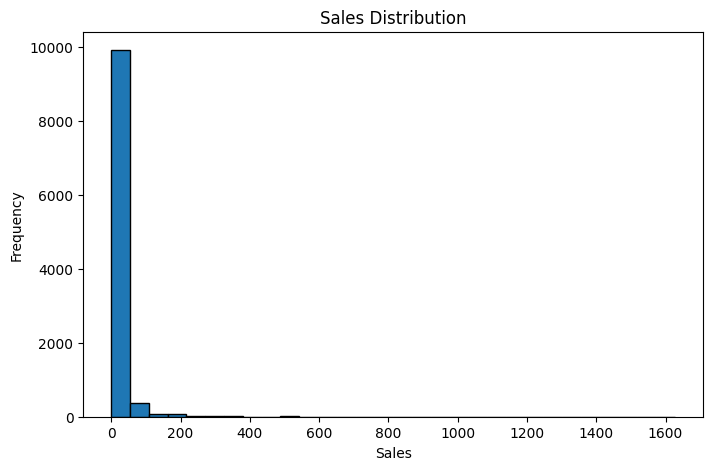

In [ ]:

plt.figure(figsize=(8,5))

plt.hist(df["Sales"], bins=30, edgecolor="black")

plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

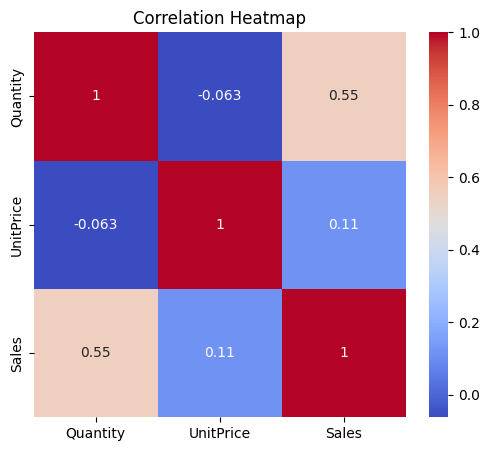

In [47]:
plt.figure(figsize=(6,5))

corr = df[["Quantity","UnitPrice","Sales"]].corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

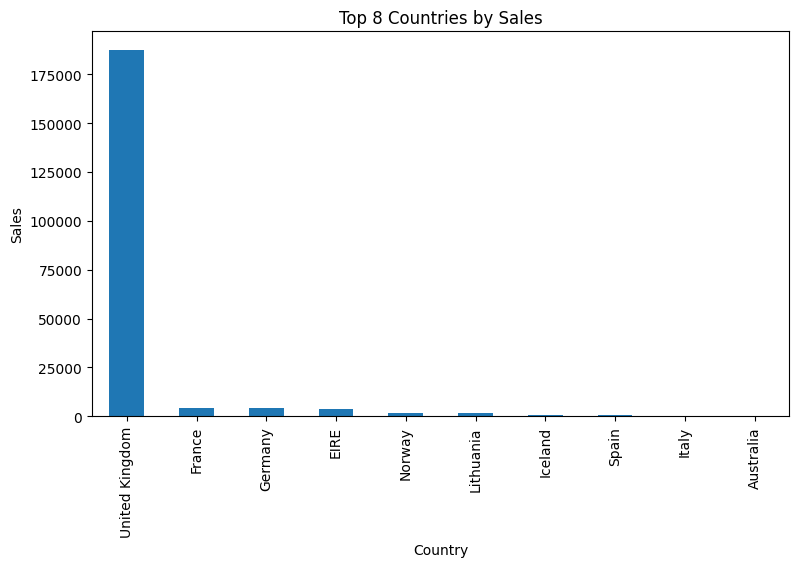

In [ ]:
country_sales = df.groupby("Country")["Sales"].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(9,5))

country_sales.plot(kind="bar")

plt.title("Top 10 Countries by Sales")

plt.ylabel("Sales")

plt.show()

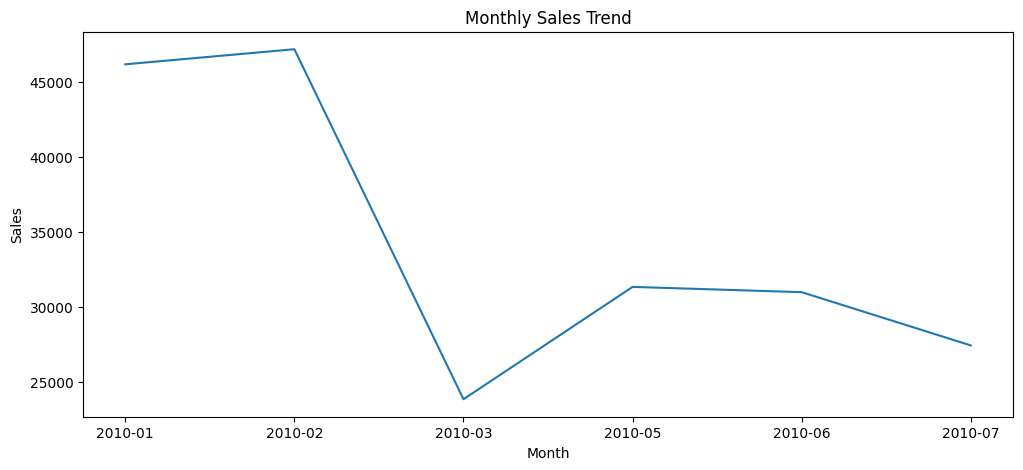

In [51]:
df["Month"] = df["InvoiceDate"].dt.to_period("M").astype(str)

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Sales Trend")

plt.ylabel("Sales")

plt.show()

In [52]:
pivot = pd.pivot_table(df,
                       values="Sales",
                       index="Country",
                       aggfunc="sum")

print(pivot)

                    Sales
Country                  
Australia          358.25
Belgium            346.10
EIRE              3788.23
France            4257.14
Germany           4242.29
Iceland            711.79
Italy              427.80
Japan              320.08
Lithuania         1598.06
Netherlands        192.60
Norway            1919.14
Poland             248.16
Portugal           261.20
Spain              620.00
Switzerland        303.40
United Kingdom  187505.94


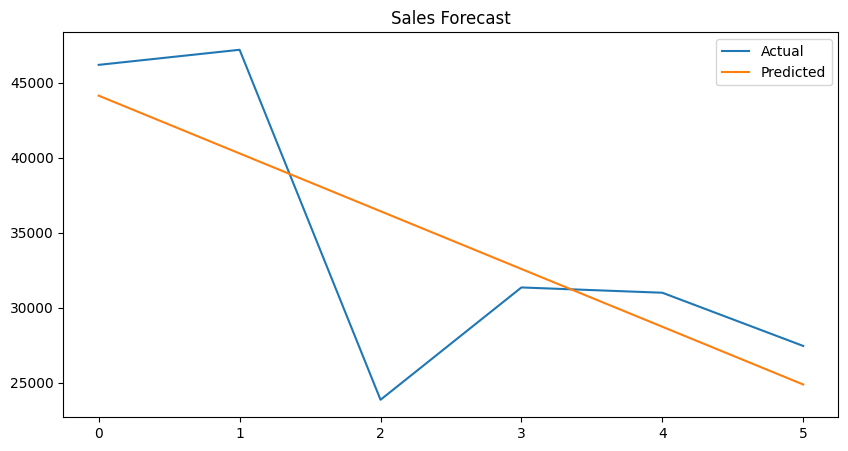

In [53]:
forecast = monthly_sales.reset_index()

forecast.columns=["Month","Sales"]

forecast["Time"] = np.arange(len(forecast))

X = forecast[["Time"]]

y = forecast["Sales"]

model = LinearRegression()

model.fit(X,y)

forecast["Prediction"] = model.predict(X)

plt.figure(figsize=(10,5))

plt.plot(forecast["Sales"],label="Actual")

plt.plot(forecast["Prediction"],label="Predicted")

plt.legend()

plt.title("Sales Forecast")

plt.show()

In [54]:
snapshot = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({

    "InvoiceDate": lambda x: (snapshot-x.max()).days,

    "InvoiceNo":"count",

    "Sales":"sum"

})

rfm.columns=["Recency","Frequency","Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12347.0,1,31,711.79
12395.0,122,12,346.10
12427.0,123,10,303.50
12431.0,182,14,358.25
12433.0,182,73,1919.14


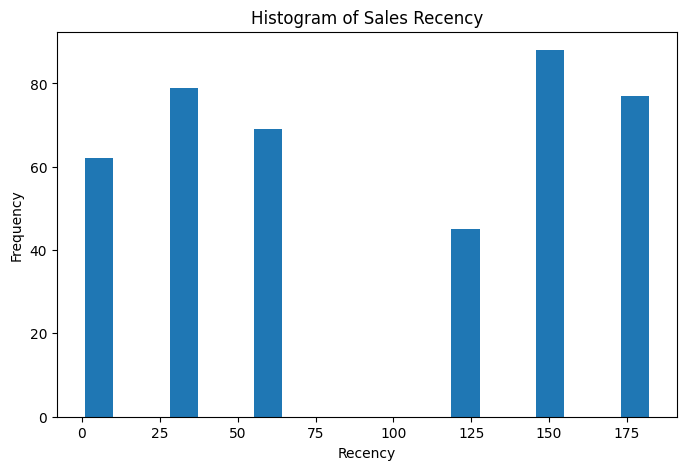

In [55]:
plt.figure(figsize=(8,5))

plt.hist(rfm["Recency"],bins=20)

plt.title("Histogram of Sales Recency")

plt.xlabel("Recency")

plt.ylabel("Frequency")

plt.show()

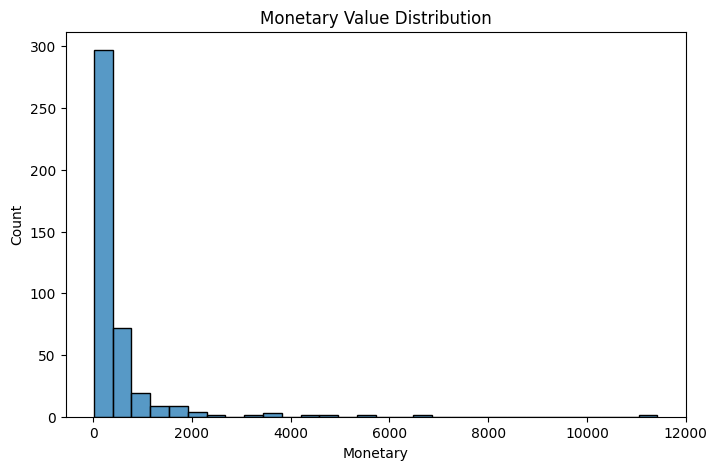

In [56]:
plt.figure(figsize=(8,5))

sns.histplot(rfm["Monetary"],bins=30)

plt.title("Monetary Value Distribution")

plt.show()

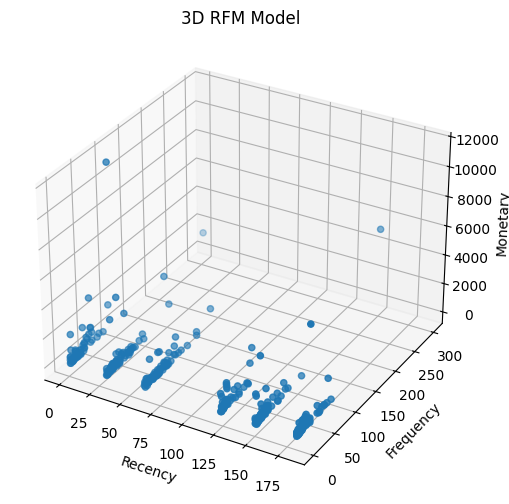

In [57]:
fig = plt.figure(figsize=(9,6))

ax = fig.add_subplot(111,projection="3d")

ax.scatter(rfm["Recency"],
           rfm["Frequency"],
           rfm["Monetary"])

ax.set_xlabel("Recency")

ax.set_ylabel("Frequency")

ax.set_zlabel("Monetary")

plt.title("3D RFM Model")

plt.show()

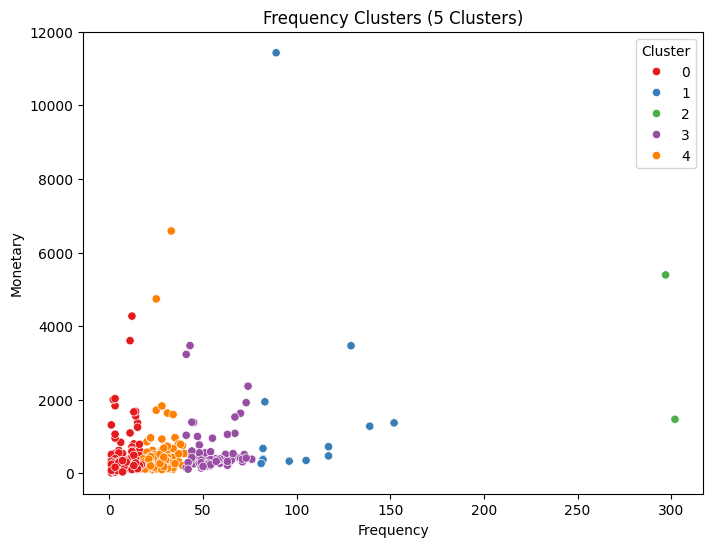

In [60]:
plt.figure(figsize=(8,6))

sns.scatterplot(data=rfm,
                x="Frequency",
                y="Monetary",
                hue="Cluster",
                palette="Set1")

plt.title("Frequency Clusters (5 Clusters)")

plt.show()

In [61]:
df.to_excel("Cleaned_Online_Retail.xlsx", index=False)

print("Dataset Saved Successfully")

Dataset Saved Successfully
